In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the Data
df = pd.read_csv(r"Marketing Campaign.csv")
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   segment          64000 non-null  str    
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), str(4)
memory usage: 5.9 MB


In [3]:
df.describe().T.iloc[:, 1:]

,mean,std,min,25%,50%,75%,max
recency,5.763734,3.507592,1.00,2.00,6.00,9.0000,12.00
history,242.085656,256.158608,29.99,64.66,158.11,325.6575,3345.93
mens,0.551031,0.497393,0.00,0.00,1.00,1.0000,1.00
womens,0.549719,0.497526,0.00,0.00,1.00,1.0000,1.00
newbie,0.502250,0.499999,0.00,0.00,1.00,1.0000,1.00
visit,0.146781,0.353890,0.00,0.00,0.00,0.0000,1.00
conversion,0.009031,0.094604,0.00,0.00,0.00,0.0000,1.00
spend,1.050908,15.036448,0.00,0.00,0.00,0.0000,499.00


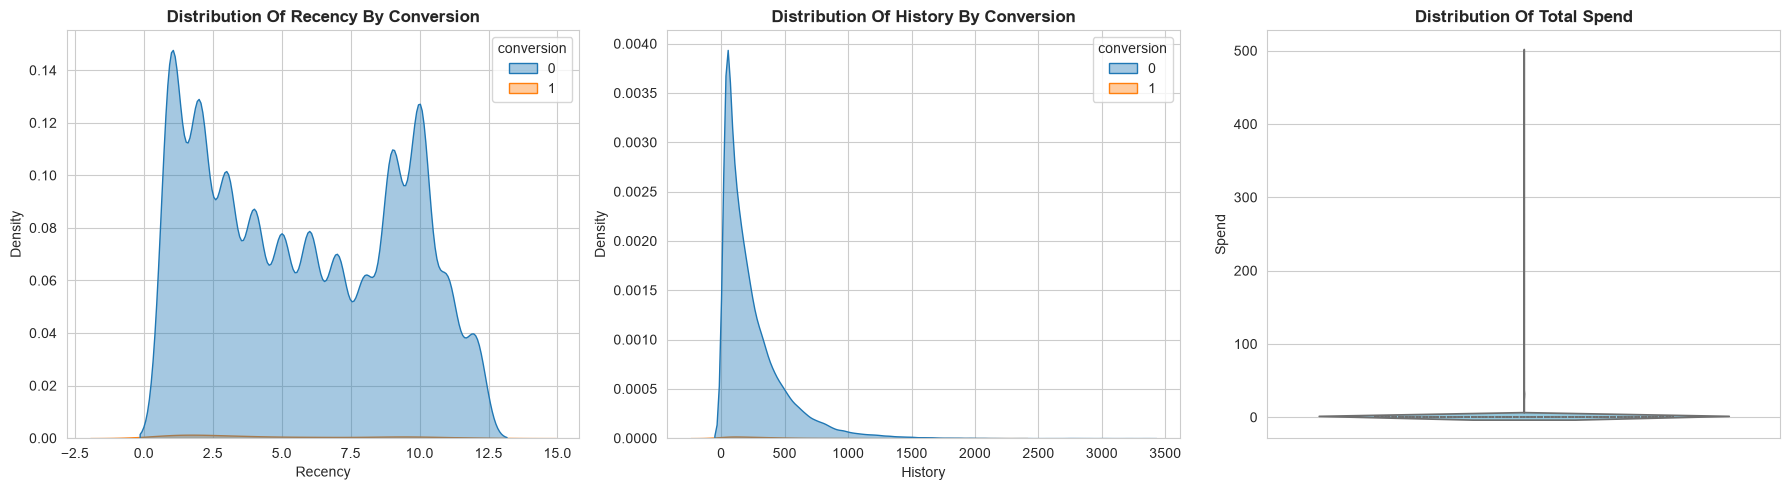

In [4]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Recency distribution by conversion
sns.kdeplot(data=df, x='recency', hue='conversion', fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title("Distribution of Recency by Conversion".title(), fontsize=12, fontweight='bold')
axes[0].set_xlabel("Recency")
axes[0].set_ylabel("Density")

# Plot 2: History distribution by conversion
sns.kdeplot(data=df, x='history', hue='conversion', fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title("Distribution of History by Conversion".title(), fontsize=12, fontweight='bold')
axes[1].set_xlabel("History")
axes[1].set_ylabel("Density")

# Plot 3: Spend distribution (violin instead of box)
sns.violinplot(y=df['spend'], ax=axes[2], color="skyblue", inner="quartile")
axes[2].set_title("Distribution of Total Spend".title(), fontsize=12, fontweight='bold')
axes[2].set_ylabel("Spend")

plt.tight_layout()
plt.show()

In [5]:
# Calculate the Conversion Rate for each Channel
df.groupby("channel")['conversion'].mean()

channel
Multichannel    0.012626
Phone           0.007744
Web             0.009321
Name: conversion, dtype: float64

In [6]:
# Calculate the Conversion Rate for each Newbie Case
df.groupby("newbie")['visit'].mean()

newbie
0    0.173060
1    0.120738
Name: visit, dtype: float64

In [7]:
# Rename the column 'segment' to make it more clarified
df = df.rename(columns={"segment": "treatment"})

# 1. Calcualte the distriubtion of treatment group
print("1. Distribution of Treatment groups:")
print(df["treatment"].value_counts(normalize=True).round(3))
print("\n" + "="*50)

# 2. Continuous Features (Means)
print("\n2. Average of Continuous Features by Treatment:")
continuous_cols = ["recency", "history"]

print(df.groupby("treatment")[continuous_cols].mean().round(2))
print("\n" + "="*50)

1. Distribution of Treatment groups:
treatment
Womens E-Mail    0.334
Mens E-Mail      0.333
No E-Mail        0.333
Name: proportion, dtype: float64


2. Average of Continuous Features by Treatment:
               recency  history
treatment                      
Mens E-Mail       5.77   242.84
No E-Mail         5.75   240.88
Womens E-Mail     5.77   242.54



In [8]:
# 3. Categorical Features (Proportions)
print("\n3. Proportions of Categorical Features by Treatment:\n")

categorical_cols = ["channel", "zip_code", "history_segment", "mens", "womens", "newbie"]

for col in categorical_cols:
    print(f"--- {col.upper()} ---")
    # Proportion for each value inside the treatment
    ct = pd.crosstab(df["treatment"], df[col], normalize="index").round(3)
    print(ct)
    print()


3. Proportions of Categorical Features by Treatment:

--- CHANNEL ---
channel        Multichannel  Phone    Web
treatment                                
Mens E-Mail           0.121  0.434  0.445
No E-Mail             0.122  0.438  0.440
Womens E-Mail         0.121  0.442  0.437

--- ZIP_CODE ---
zip_code       Rural  Surburban  Urban
treatment                             
Mens E-Mail    0.152      0.446  0.402
No E-Mail      0.147      0.452  0.401
Womens E-Mail  0.149      0.451  0.400

--- HISTORY_SEGMENT ---
history_segment  1) $0 - $100  2) $100 - $200  3) $200 - $350  4) $350 - $500  \
treatment                                                                       
Mens E-Mail             0.363           0.220           0.192           0.098   
No E-Mail               0.357           0.227           0.190           0.100   
Womens E-Mail           0.357           0.221           0.194           0.102   

history_segment  5) $500 - $750  6) $750 - $1,000  7) $1,000 +  
treatment 

womens             0      1
treatment                  
Mens E-Mail    0.449  0.551
No E-Mail      0.452  0.548
Womens E-Mail  0.450  0.550

--- NEWBIE ---
newbie             0      1
treatment                  
Mens E-Mail    0.498  0.502
No E-Mail      0.498  0.502
Womens E-Mail  0.497  0.503



In [9]:
from scipy.stats import chi2_contingency, f_oneway

print("\n4. Statistical Tests for Balance:\n")

# Calculate the ANOVA for Continuis values
for col in ["recency", "history"]:
    groups = [group[col].values for name, group in df.groupby("treatment")]
    stat, p = f_oneway(*groups)
    print(f"{col}: p-value = {p:.4f}  {'(Balanced)' if p > 0.05 else '(Not Balanced!)'}")

print()

# Chi-Square for Categorical
for col in categorical_cols:
    contingency = pd.crosstab(df["treatment"], df[col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: p-value = {p:.4f}  {'(Balanced)' if p > 0.05 else '(Not Balanced!)'}")


4. Statistical Tests for Balance:

recency: p-value = 0.7631  (Balanced)
history: p-value = 0.6980  (Balanced)

channel: p-value = 0.4580  (Balanced)
zip_code: p-value = 0.5795  (Balanced)
history_segment: p-value = 0.3580  (Balanced)
mens: p-value = 0.6717  (Balanced)
womens: p-value = 0.7289  (Balanced)
newbie: p-value = 0.9339  (Balanced)


In [10]:
# Calculate the Conversion Rate for each treatment
conversion_rate = (
    df.groupby("treatment")["conversion"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Customers",
        "sum": "Converters",
        "mean": "Conversion Rate"
    })
)

# Formatting proportion
conversion_rate["Conversion Rate"] = (conversion_rate["Conversion Rate"] * 100).round(2)

print(conversion_rate)

               Total Customers  Converters  Conversion Rate
treatment                                                  
Mens E-Mail              21307         267             1.25
No E-Mail                21306         122             0.57
Womens E-Mail            21387         189             0.88


In [11]:
# Calculate the Visit Rate for each treatment
visit_rate = (
    df.groupby("treatment")["visit"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Customers",
        "sum": "Visitors",
        "mean": "Visit Rate"
    })
)

# Formatting Proportion
visit_rate["Visit Rate"] = (visit_rate["Visit Rate"] * 100).round(2)

print(visit_rate)

               Total Customers  Visitors  Visit Rate
treatment                                           
Mens E-Mail              21307      3894       18.28
No E-Mail                21306      2262       10.62
Womens E-Mail            21387      3238       15.14


In [12]:
# 1. Revenue summary
revenue_summary = (
    df.groupby("treatment")["spend"]
    .agg(
        Total_Customers = "count",
        Mean_Spend = "mean",
        Median_Spend = "median",
        Total_Revenue = "sum"
    )
    .round(2)
)

print("=== Overall Revenue Analysis (including zeros) ===")
print(revenue_summary)
print("\n")

# 2. Revenue among Converters only
converters = df[df["conversion"] == 1]

revenue_converters = (
    converters.groupby("treatment")["spend"]
    .agg(
        Number_of_Buyers = "count",
        Mean_Spend = "mean",
        Median_Spend = "median",
        Total_Revenue = "sum"
    )
    .round(2)
)

print("=== Revenue among Buyers only (conversion = 1) ===")
print(revenue_converters)

=== Overall Revenue Analysis (including zeros) ===
               Total_Customers  Mean_Spend  Median_Spend  Total_Revenue
treatment                                                              
Mens E-Mail              21307        1.42           0.0       30311.69
No E-Mail                21306        0.65           0.0       13908.33
Womens E-Mail            21387        1.08           0.0       23038.11


=== Revenue among Buyers only (conversion = 1) ===
               Number_of_Buyers  Mean_Spend  Median_Spend  Total_Revenue
treatment                                                               
Mens E-Mail                 267      113.53         66.98       30311.69
No E-Mail                   122      114.00         88.36       13908.33
Womens E-Mail               189      121.89         94.71       23038.11


In [13]:
from statsmodels.stats.proportion import proportions_ztest
def two_proportion_ztest(group1, group2, data=df):
    """
    group1, group2: The names of treatments
    """
    g1 = data[data["treatment"] == group1]["conversion"]
    g2 = data[data["treatment"] == group2]["conversion"]
    
    successes = [g1.sum(), g2.sum()]
    nobs = [len(g1), len(g2)]
    
    z_stat, p_value = proportions_ztest(successes, nobs, alternative='two-sided')
    
    print(f"\n=== {group1} vs {group2} ===")
    print(f"Conversion Rate {group1}: {g1.mean()*100:.2f}%")
    print(f"Conversion Rate {group2}: {g2.mean()*100:.2f}%")
    print(f"Z-statistic: {z_stat:.3f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("Statistically Significant Difference ✓")
    else:
        print("→ The difference is not Significant ✗")

# Experiments
two_proportion_ztest("Mens E-Mail", "No E-Mail")
two_proportion_ztest("Womens E-Mail", "No E-Mail")
two_proportion_ztest("Mens E-Mail", "Womens E-Mail")


=== Mens E-Mail vs No E-Mail ===
Conversion Rate Mens E-Mail: 1.25%
Conversion Rate No E-Mail: 0.57%
Z-statistic: 7.385
P-value: 0.0000
Statistically Significant Difference ✓

=== Womens E-Mail vs No E-Mail ===
Conversion Rate Womens E-Mail: 0.88%
Conversion Rate No E-Mail: 0.57%
Z-statistic: 3.780
P-value: 0.0002
Statistically Significant Difference ✓

=== Mens E-Mail vs Womens E-Mail ===
Conversion Rate Mens E-Mail: 1.25%
Conversion Rate Womens E-Mail: 0.88%
Z-statistic: 3.713
P-value: 0.0002
Statistically Significant Difference ✓


In [14]:
from scipy.stats import chi2_contingency

# Make a frequency table
contingency_table = pd.crosstab(df["treatment"], df["conversion"])
print("Contingency Table:")
print(contingency_table)
print()

# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("=== Chi-Square Test ===")
print(f"Chi2 Statistic: {chi2:.3f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ There is a Significant Difference between the groups ✓")
else:
    print("→ There is no Significant Difference ✗")

Contingency Table:
conversion         0    1
treatment                
Mens E-Mail    21040  267
No E-Mail      21184  122
Womens E-Mail  21198  189

=== Chi-Square Test ===
Chi2 Statistic: 55.258
Degrees of Freedom: 2
P-value: 0.0000
→ There is a Significant Difference between the groups ✓


In [15]:
from scipy.stats import chi2_contingency, f_oneway, kruskal

print("="*60)
print("1. Chi-Square Test (Categorical Features)")
print("="*60)

categorical_cols = ["channel", "newbie", "zip_code", "mens", "womens", "history_segment"]

for col in categorical_cols:
    contingency = pd.crosstab(df["treatment"], df[col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    status = "Balanced ✓" if p > 0.05 else "Not Balanced ✗"
    print(f"{col:18} → p-value = {p:.4f}  |  {status}")

print("\n" + "="*60)
print("2. ANOVA Test (Numerical Features)")
print("="*60)

numerical_cols = ["history", "recency"]

for col in numerical_cols:
    groups = [group[col].values for name, group in df.groupby("treatment")]
    stat, p = f_oneway(*groups)
    
    status = "Balanced ✓" if p > 0.05 else "Not Balanced ✗"
    print(f"{col:18} → p-value = {p:.4f}  |  {status}")

print("\n" + "="*60)
print("3. Kruskal-Wallis Test (Non-parametric alternative)")
print("="*60)

for col in numerical_cols:
    groups = [group[col].values for name, group in df.groupby("treatment")]
    stat, p = kruskal(*groups)
    
    status = "Balanced ✓" if p > 0.05 else "Not Balanced ✗"
    print(f"{col:18} → p-value = {p:.4f}  |  {status}")

1. Chi-Square Test (Categorical Features)
channel            → p-value = 0.4580  |  Balanced ✓
newbie             → p-value = 0.9339  |  Balanced ✓
zip_code           → p-value = 0.5795  |  Balanced ✓
mens               → p-value = 0.6717  |  Balanced ✓
womens             → p-value = 0.7289  |  Balanced ✓
history_segment    → p-value = 0.3580  |  Balanced ✓

2. ANOVA Test (Numerical Features)
history            → p-value = 0.6980  |  Balanced ✓
recency            → p-value = 0.7631  |  Balanced ✓

3. Kruskal-Wallis Test (Non-parametric alternative)
history            → p-value = 0.6669  |  Balanced ✓
recency            → p-value = 0.7941  |  Balanced ✓


In [16]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Transform the categorical columns
df["newbie"] = df["newbie"].astype(str)          # So that act as categorical
df["mens"] = df["mens"].astype(str)
df["womens"] = df["womens"].astype(str)

# Build the model
model = smf.logit(
    formula = """
    conversion ~ 
        C(treatment, Treatment(reference='No E-Mail')) + 
        history + 
        recency + 
        C(newbie) + 
        C(channel) + 
        C(zip_code)
    """,
    data = df
).fit(disp=0)

# Show outputs
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:             conversion   No. Observations:                64000
Model:                          Logit   Df Residuals:                    63990
Method:                           MLE   Df Model:                            9
Date:                Mon, 27 Jul 2026   Pseudo R-squ.:                 0.02375
Time:                        17:09:56   Log-Likelihood:                -3217.8
converged:                       True   LL-Null:                       -3296.1
Covariance Type:            nonrobust   LLR p-value:                 3.898e-29
                                                                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------
Intercept                                                          -4.5763      0.190    -24.024      0.

In [17]:
# Calculate the lift based on the history segment
hte_segment = (
    df.groupby(["history_segment", "treatment"])["conversion"]
    .mean()
    .unstack()
)

hte_segment["Lift_Mens"] = (hte_segment["Mens E-Mail"] - hte_segment["No E-Mail"]) * 100
hte_segment["Lift_Womens"] = (hte_segment["Womens E-Mail"] - hte_segment["No E-Mail"]) * 100

print(hte_segment[["Lift_Mens", "Lift_Womens"]].round(2))

treatment         Lift_Mens  Lift_Womens
history_segment                         
1) $0 - $100           0.50         0.38
2) $100 - $200         0.48         0.37
3) $200 - $350         0.85        -0.07
4) $350 - $500         0.87        -0.22
5) $500 - $750         0.83         1.02
6) $750 - $1,000       2.00         0.87
7) $1,000 +            0.93         1.13
